In [4]:
from ultralytics import YOLO
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, quantize_static, CalibrationDataReader, QuantType

import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

import torch

import os

import cv2

# Create Onnx

In [5]:
model = YOLO("piece_yolo.pt")
model.export(format="onnx",
             opset=13,
             simplify=True,
             dynamic=True,
            #  half=True,
            #  device=0
            )

Ultralytics 8.3.201 🚀 Python-3.13.3 torch-2.7.1+cu126 CPU (Intel Core(TM) i7-9750H 2.60GHz)
Model summary (fused): 72 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'piece_yolo.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 16, 8400) (6.0 MB)

ONNX: starting export with onnx 1.19.1 opset 13...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 3.3s, saved as 'piece_yolo.onnx' (11.8 MB)

Export complete (3.7s)
Results saved to /mnt/D/University/Thesis/src/compression
Predict:         yolo predict task=detect model=piece_yolo.onnx imgsz=640  
Validate:        yolo val task=detect model=piece_yolo.onnx imgsz=640 data=/content/drive/MyDrive/Thesis se7s Fall2025/SuperTrainPrep/data.yaml  
Visualize:       https://netron.app


'piece_yolo.onnx'

# Running Models

In [ ]:
img = Image.open("/mnt/D/University/Thesis_Dataset/Dataset/Images/image_27.jpg").resize((640,640))
x = np.array(img).transpose(2,0,1)[None, :, :, :] / 255
x = x.astype(np.float32)

results = model(img)
# results = model(torch.flip(ds[0][0], (0,)).unsqueeze(0))
results[0].show()

0: 640x640 2 black-bishops, 1 black-king, 1 black-knight, 6 black-pawns, 2 black-queens, 2 black-rooks, 1 white-bishop, 4 white-knights, 1 white-pawn, 1 white-queen, 1 white-rook, 110.0ms
Speed: 0.0ms preprocess, 110.0ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


Opening in existing browser session.


In [29]:
session = ort.InferenceSession(
                                "piece_yolo.onnx",
                                # "piece_yolo_quantized_dynamic.onnx",
                                # "piece_yolo_quantized_static.onnx",
                               providers=["CPUExecutionProvider"],
                              #  providers=["CUDAExecutionProvider"]
                               )

outputs = session.run(None, {"images": x})
print(len(outputs), [o.shape for o in outputs])

1 [(1, 16, 8400)]


# Viewing Onnx Results

In [30]:
# 0: 'black-bishop',
#  1: 'black-king',
#  2: 'black-knight',
#  3: 'black-pawn',
#  4: 'black-queen',
#  5: 'black-rook',
#  6: 'white-bishop',
#  7: 'white-king',
#  8: 'white-knight',
#  9: 'white-pawn',
#  10: 'white-queen',
#  11: 'white-rook

In [31]:
res = outputs[0][0]

confidence_threshold = 0.5
nms_threshold = 0.45

# OpenCV's NMS
indices = cv2.dnn.NMSBoxes(
    bboxes=res[:4].T.tolist(),  # Convert to list of [x, y, w, h] or keep [x1, y1, x2, y2]
    scores=res[4:].max(axis=0).tolist(),
    score_threshold=confidence_threshold,
    nms_threshold=nms_threshold
)

print(indices)

# Get filtered results
if len(indices) > 0:
    res = res[:,indices.flatten()]

[1458 1172 6569  996  921 4418 3637 2222 2757 6693  777 6775 6613 6582 2275 3579 2858 3619 6817]


In [32]:
cx = res[0]
cy = res[1]
w = res[2]
h = res[3]

x1 = cx - w / 2
y1 = cy - h / 2
x2 = cx + w / 2
y2 = cy + h / 2

corners = np.stack([
    x1,y1,x2,y2
], axis=1)

corners = np.stack([np.array([
    [row[0], row[1]],
    [row[2], row[1]],
    [row[2], row[3]],
    [row[0], row[3]],
]) for row in corners])

corners.shape

(19, 4, 2)

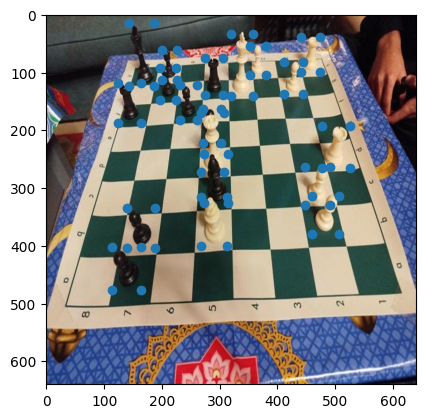

In [33]:
viewed_corners = corners
# viewed_corners = corners[res[4:].argmax(axis=0) == 3]
viewed_corners = viewed_corners.reshape(-1,2)

plt.imshow(img);
results = plt.scatter(viewed_corners[:,0], viewed_corners[:,1]);

# Testing Runtime

In [34]:
session.get_providers()

['CPUExecutionProvider']

In [35]:
%%timeit
outputs = session.run(None, {"images": x})

87.9 ms ± 5.37 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Optimize Onnx (Dynamic Quantization)

In [173]:
model_onnx = onnx.load("piece_yolo.onnx")
onnx.checker.check_model(model_onnx)

In [180]:
model_fp32 = "piece_yolo.onnx"
model_int8 = "piece_yolo_quantized_dynamic.onnx"

quantize_dynamic(
    model_input=model_fp32,
    model_output=model_int8,
    weight_type=QuantType.QUInt8,  # or QuantType.QUInt8
    # op_types_to_quantize=["MatMul", "Gemm"]
)

# Optimize Onnx (Static Quantization)

In [2]:
from Dataset.DataSetLoaders import ChessDataset
from PieceDetection.PieceCropper_3D import PieceCropper

In [13]:
ds = ChessDataset.ChessDataset(
    config={
        "img_size": (640,640)
    }
)

def prep(entry):
    img, lbl = entry
    return torch.flip(img, (0,)).unsqueeze(0)

class CalibrationDataReader(CalibrationDataReader):
    def __init__(self, input_name):
        self.input_name = input_name
        self.data_iter = iter([
            {input_name: prep(ds[_]).numpy()}
            for _ in range(10)
        ])

    def get_next(self):
        return next(self.data_iter, None)

In [14]:
# load model to find input name
model_fp32 = "piece_yolo.onnx"
session = ort.InferenceSession(model_fp32, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

dr = CalibrationDataReader(input_name)

quantize_static(
    model_input=model_fp32,
    model_output="piece_yolo_quantized_static.onnx",
    calibration_data_reader=dr,
    weight_type=QuantType.QInt16,
)
print("✅ Static quantization done")

✅ Static quantization done
